In [1]:
import requests
import folium
from folium import plugins
import random
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import optuna
import scipy.spatial as spatial
from sklearn.cluster import KMeans

optuna.logging.set_verbosity(optuna.logging.WARNING)
random.seed(42)
np.random.seed(42)

OUT_DIR = "hasil_optimasi_eas"
os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 90)
print("EAS — PSO MULTI-CONSTRAINT (Fatigue + Road Condition + Cluster + Daily Dist)")
print("Referensi: ETS PSO dengan Optuna Tuning | 10 Independent Run | Avg/Std/Min/AvgTime")
print("=" * 90)

/Users/mac/sc_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EAS — PSO MULTI-CONSTRAINT (Fatigue + Road Condition + Cluster + Daily Dist)
Referensi: ETS PSO dengan Optuna Tuning | 10 Independent Run | Avg/Std/Min/AvgTime


In [2]:
# ==========================================
# 1) DATASET — 31 LOKASI WISATA SURABAYA
# ==========================================
locations = {
    "1. Monumen Kapal Selam":              {"coord": (-7.2654,   112.7503),  "elev": 4.0},
    "2. Tugu Pahlawan":                    {"coord": (-7.2453,   112.7379),  "elev": 9.0},
    "3. Jembatan Merah":                   {"coord": (-7.2365,   112.7383),  "elev": 6.0},
    "4. Hotel Majapahit":                  {"coord": (-7.2573,   112.7388),  "elev": 9.0},
    "5. Balai Kota Surabaya":              {"coord": (-7.2589,   112.7469),  "elev": 6.0},
    "6. House of Sampoerna":               {"coord": (-7.2306,   112.7343),  "elev": 6.0},
    "7. Museum Surabaya (Siola)":          {"coord": (-7.2514,   112.7363),  "elev": 7.0},
    "8. Rumah WR Soepratman":              {"coord": (-7.2504,   112.7538),  "elev": 5.0},
    "9. Gedung De Javasche Bank":          {"coord": (-7.2365,   112.7358),  "elev": 11.0},
    "10. Gereja Katolik Kepanjen":         {"coord": (-7.2435,   112.7335),  "elev": 6.0},
    "11. Jembatan Petekan":                {"coord": (-7.222192, 112.738044),"elev": 5.0},
    "12. Gedung Internatio":               {"coord": (-7.236281, 112.736915),"elev": 11.0},
    "13. Gedung Negara Grahadi":           {"coord": (-7.263524, 112.743179),"elev": 7.0},
    "14. Kantor Pos Kebon Rojo":           {"coord": (-7.243218, 112.737700),"elev": 6.0},
    "15. Rumah HOS Tjokroaminoto":         {"coord": (-7.252464, 112.737747),"elev": 7.0},
    "16. Makam Belanda Peneleh":           {"coord": (-7.253019, 112.740353),"elev": 5.0},
    "17. Kampung Lawang Seketeng":         {"coord": (-7.250495, 112.740751),"elev": 7.0},
    "18. Gerbang Depan ITS":               {"coord": (-7.279395, 112.790094),"elev": 3.0},
    "19. Gedung Cerutu":                   {"coord": (-7.236097, 112.737047),"elev": 11.0},
    "20. Patung Karapan Sapi":             {"coord": (-7.272209, 112.742095),"elev": 26.0},
    "21. Klenteng Sanggar Agung":          {"coord": (-7.247199, 112.802195),"elev": 0.0},
    "22. Museum Pendidikan":               {"coord": (-7.255254, 112.742785),"elev": 6.0},
    "23. Klenteng Hong Tiek Hian":         {"coord": (-7.236797, 112.743875),"elev": 5.0},
    "24. Monumen Bambu Runcing":           {"coord": (-7.267096, 112.744184),"elev": 7.0},
    "25. Taman Prestasi":                  {"coord": (-7.261174, 112.742914),"elev": 5.0},
    "26. Penjara Kalisosok":               {"coord": (-7.2343,   112.7351),  "elev": 5.0},
    "27. Masjid Nasional Al-Akbar":        {"coord": (-7.3381,   112.7148),  "elev": 12.0},
    "28. Jembatan Suroboyo (Kenjeran)":    {"coord": (-7.2515,   112.7964),  "elev": 2.0},
    "29. Monumen Jenderal Sudirman":       {"coord": (-7.2736,   112.7441),  "elev": 8.0},
    "30. Kawasan Kota Tua Kembang Jepun":  {"coord": (-7.2384,   112.7412),  "elev": 6.0},
    "31. Pura Agung Jagat Karana":         {"coord": (-7.2325,   112.7291),  "elev": 5.0},
}

names           = list(locations.keys())
coords_values   = [loc["coord"] for loc in locations.values()]
elevations_list = [loc["elev"]  for loc in locations.values()]
n               = len(locations)
NUM_CITIES      = n

START_CITY         = "18. Gerbang Depan ITS"
start_location_idx = names.index(START_CITY)

print(f"Total Destinasi  : {NUM_CITIES} lokasi")
print(f"Depot Start/End  : {START_CITY} (idx {start_location_idx})")

Total Destinasi  : 31 lokasi
Depot Start/End  : 18. Gerbang Depan ITS (idx 17)


In [3]:
# ==========================================
# 2) OSRM DISTANCE MATRIX — BIKE ROUTING (CACHE)
# ==========================================
cache_path = os.path.join(OUT_DIR, "distance_matrix_km.npy")

if os.path.exists(cache_path):
    print("\n💾 Load distance matrix dari cache...")
    distance_matrix = np.load(cache_path)
else:
    print("\n📡 Menarik Distance Matrix SEPEDA dari OSRM...")
    coords_list   = [f"{lon},{lat}" for lat, lon in coords_values]
    coords_string = ";".join(coords_list)
    url = (f"http://router.project-osrm.org/table/v1/bike/"
           f"{coords_string}?annotations=distance")
    response = requests.get(url, timeout=60).json()
    if response.get("code") != "Ok":
        raise RuntimeError(f"OSRM Error: {response}")
    distance_matrix = np.array(response["distances"]) / 1000.0
    np.save(cache_path, distance_matrix)
    print("✅ Distance Matrix SEPEDA tersimpan ke cache!")

print(f"Shape: {distance_matrix.shape} (unit: km)")


📡 Menarik Distance Matrix SEPEDA dari OSRM...
✅ Distance Matrix SEPEDA tersimpan ke cache!
Shape: (31, 31) (unit: km)


In [4]:
# ==========================================
# 3) SPATIAL CLUSTERING (K-MEANS 3 KLUSTER)
#    + ROAD CONDITION MATRIX
# ==========================================

# --- K-Means Clustering berbasis koordinat geografis ---
coords_arr    = np.array(coords_values)
km_model      = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km_model.fit_predict(coords_arr)

df_cluster = pd.DataFrame({
    "Nama":       names,
    "Lat":        [c[0] for c in coords_values],
    "Lon":        [c[1] for c in coords_values],
    "Elevation":  elevations_list,
    "Cluster_ID": cluster_labels,
})

print("Distribusi Kluster Geografis (K-Means, k=3):")
for c_id in sorted(df_cluster["Cluster_ID"].unique()):
    members = df_cluster[df_cluster["Cluster_ID"] == c_id]["Nama"].tolist()
    print(f"  Kluster {c_id} ({len(members)} dest.): {', '.join(members[:4])} ...")

# --- Road Condition Matrix ---
# Intra-cluster = 1.5 (jalan lokal / ramah sepeda)
# Cross-cluster = 4.0 (jalan protokol padat kendaraan)
road_matrix = np.where(
    cluster_labels[:, None] == cluster_labels[None, :], 1.5, 4.0
)
np.fill_diagonal(road_matrix, 0.0)

print(f"\nRoad Condition Matrix ({NUM_CITIES}x{NUM_CITIES}) — cuplikan 4x4:")
sample_idx = [0, 1, 10, 17]
sample_names = [names[i][:20] for i in sample_idx]
print(pd.DataFrame(road_matrix[np.ix_(sample_idx, sample_idx)],
                   index=sample_names, columns=sample_names).round(1).to_string())

Distribusi Kluster Geografis (K-Means, k=3):
  Kluster 0 (1 dest.): 27. Masjid Nasional Al-Akbar ...
  Kluster 1 (27 dest.): 1. Monumen Kapal Selam, 2. Tugu Pahlawan, 3. Jembatan Merah, 4. Hotel Majapahit ...
  Kluster 2 (3 dest.): 18. Gerbang Depan ITS, 21. Klenteng Sanggar Agung, 28. Jembatan Suroboyo (Kenjeran) ...

Road Condition Matrix (31x31) — cuplikan 4x4:
                      1. Monumen Kapal Sel  2. Tugu Pahlawan  11. Jembatan Petekan  18. Gerbang Depan IT
1. Monumen Kapal Sel                   0.0               1.5                   1.5                   4.0
2. Tugu Pahlawan                       1.5               0.0                   1.5                   4.0
11. Jembatan Petekan                   1.5               1.5                   0.0                   4.0
18. Gerbang Depan IT                   4.0               4.0                   4.0                   0.0


In [5]:
# ==========================================
# 4) PARAMETER CONSTRAINT & PENALTY
# ==========================================

# ── Constraint ETS (dari UTS — dipertahankan) ───────────────
LAMBDA_FATIGUE    = 2.5    # Bobot penalti fatigue dalam fitness
MU_VIOLATIONS     = 10.0   # Penalti per pelanggaran elevasi ekstrem
RECOVERY_FACTOR   = 0.82   # Faktor pemulihan kelelahan antar langkah (0<r<1)
EXTREME_EFFORT_M  = 0.5    # Ambang batas selisih elevasi naik (m) → dihitung pelanggaran

# ── Constraint EAS Tambahan (baru di UAS) ───────────────────
MAX_KM_PER_DAY    = 20.0   # Soft constraint jarak harian maksimum (km)
W_ROAD            = 0.30   # Bobot komponen road condition dalam fitness
W_CLUSTER_PEN     = 5.0    # Penalti per perpindahan antar kluster
W_DAY_DIST_PEN    = 8.0    # Penalti per km kelebihan dari MAX_KM_PER_DAY

print("=" * 55)
print("Constraint yang Aktif:")
print("=" * 55)
print(f"  [ETS] LAMBDA_FATIGUE   = {LAMBDA_FATIGUE}")
print(f"  [ETS] MU_VIOLATIONS    = {MU_VIOLATIONS}")
print(f"  [ETS] RECOVERY_FACTOR  = {RECOVERY_FACTOR}")
print(f"  [ETS] EXTREME_EFFORT_M = {EXTREME_EFFORT_M} m")
print(f"  [EAS] MAX_KM_PER_DAY   = {MAX_KM_PER_DAY} km (soft)")
print(f"  [EAS] W_ROAD           = {W_ROAD}")
print(f"  [EAS] W_CLUSTER_PEN    = {W_CLUSTER_PEN}")
print(f"  [EAS] W_DAY_DIST_PEN   = {W_DAY_DIST_PEN}")

Constraint yang Aktif:
  [ETS] LAMBDA_FATIGUE   = 2.5
  [ETS] MU_VIOLATIONS    = 10.0
  [ETS] RECOVERY_FACTOR  = 0.82
  [ETS] EXTREME_EFFORT_M = 0.5 m
  [EAS] MAX_KM_PER_DAY   = 20.0 km (soft)
  [EAS] W_ROAD           = 0.3
  [EAS] W_CLUSTER_PEN    = 5.0
  [EAS] W_DAY_DIST_PEN   = 8.0


In [6]:
# ==========================================
# 5) FUNGSI FITNESS
#    - get_metrics()          → fitness dasar (ETS-style, untuk kompatibilitas Optuna)
#    - get_metrics_multiday() → fitness lengkap EAS (+ road + cluster + daily dist)
# ==========================================

def get_metrics(route):
    """
    Fitness dasar (kompatibel ETS).
    route : list index [start, ..., start]
    Returns: score, dist_km, max_fatigue, violations, fatigue_history
    """
    dist        = 0.0
    fatigue     = 0.0
    max_fatigue = 0.0
    violations  = 0
    f_history   = [0.0]

    for i in range(len(route) - 1):
        c   = route[i]
        nxt = route[i + 1]
        dist += distance_matrix[c][nxt]

        elev_diff = elevations_list[nxt] - elevations_list[c]
        effort    = max(0.0, elev_diff)

        if effort > EXTREME_EFFORT_M:
            violations += 1

        fatigue     = (fatigue + effort) * RECOVERY_FACTOR
        max_fatigue = max(max_fatigue, fatigue)
        f_history.append(fatigue)

    score = dist + (LAMBDA_FATIGUE * max_fatigue) + (MU_VIOLATIONS * violations)
    return score, dist, max_fatigue, violations, f_history


def get_metrics_multiday(route):
    """
    Fitness EAS lengkap:
      base_score (ETS) + road_condition + cluster_penalty + daily_dist_penalty

    route : list index [start, ..., start]
    Returns: total_score, dist_km, max_fatigue, violations
    """
    base_score, dist, max_fatigue, violations, _ = get_metrics(route)

    # Komponen Road Condition (skor jalan sepanjang rute)
    road_score = sum(
        road_matrix[route[i]][route[i + 1]]
        for i in range(len(route) - 1)
    )

    # Komponen Cluster Penalty (banyak perpindahan lintas wilayah)
    cluster_pen = 0.0
    for i in range(len(route) - 1):
        ci = route[i]
        cj = route[i + 1]
        # Abaikan perjalanan yang melibatkan depot (idx 0 / start_location_idx)
        if ci != start_location_idx and cj != start_location_idx:
            if cluster_labels[ci] != cluster_labels[cj]:
                cluster_pen += 1.0

    # Komponen Daily Distance Penalty (soft: hukum jika > MAX_KM_PER_DAY)
    day_dist_pen = max(0.0, dist - MAX_KM_PER_DAY) * W_DAY_DIST_PEN

    total_score = (base_score
                   + W_ROAD * road_score
                   + W_CLUSTER_PEN * cluster_pen
                   + day_dist_pen)

    return total_score, dist, max_fatigue, violations


def compliance_percent(violations, legs):
    if legs <= 0:
        return 0.0
    return 100.0 * (legs - violations) / legs


print("✅ Fungsi fitness (ETS + EAS) siap digunakan.")

✅ Fungsi fitness (ETS + EAS) siap digunakan.


In [7]:
# ==========================================
# 6) PARTICLE SWARM OPTIMIZATION (PSO) — EAS
#
#  Pembaruan dari ETS:
#  ► Fitness function diperluas: road condition
#    matrix + cluster penalty + daily dist penalty
#  ► Swap-Sequence Operator (SO) tetap dipertahankan
#  ► Validasi integritas permutasi tetap dipertahankan
#  ► Optuna tuning: num_particles, w, c1, c2
#  ► 10 independent run → Avg, Std Dev, Min, Avg Time
# ==========================================

print("\n" + "=" * 60)
print("🕊️  PSO EAS — Optuna Hyperparameter Tuning (30 Trials)")
print("=" * 60)


# ── Swap-Sequence Operator (dari ETS, dipertahankan) ─────────
def pso_swap_sequence(route_a, route_b):
    """Hitung urutan swap (SO) yang mengubah route_a → route_b."""
    a, b   = list(route_a), list(route_b)
    swaps  = []
    for i in range(len(b)):
        if a[i] != b[i]:
            j = a.index(b[i], i)
            swaps.append((i, j))
            a[i], a[j] = a[j], a[i]
    return swaps


def pso_apply_swaps(route, swaps):
    r = list(route)
    for i, j in swaps:
        r[i], r[j] = r[j], r[i]
    return r


# ── Core PSO ─────────────────────────────────────────────────
def run_pso(num_particles=40, iterations=150,
            w=0.5, c1=1.5, c2=1.5, seed=42):
    """
    PSO untuk optimasi rute wisata sepeda Surabaya.

    Komponen kecepatan (dalam ruang permutasi diskrit):
      v_new = w * v_inertia  +  c1*r1 * (pbest - x)  +  c2*r2 * (gbest - x)

    Representasi: permutasi indeks kota (tanpa depot),
    dijadikan rute penuh via  [depot] + perm + [depot].

    Parameters
    ----------
    num_particles : ukuran swarm
    iterations    : maks iterasi
    w             : bobot inersia
    c1            : koefisien kognitif (personal best)
    c2            : koefisien sosial   (global best)
    seed          : random seed untuk reprodusibilitas

    Returns
    -------
    best_route         : list indeks rute terbaik [start…start]
    best_score_history : list skor terbaik per iterasi
    """
    random.seed(seed)
    np.random.seed(seed)

    other_cities = [i for i in range(NUM_CITIES) if i != start_location_idx]

    def to_full_route(perm):
        return [start_location_idx] + perm + [start_location_idx]

    def eval_perm(perm):
        return get_metrics_multiday(to_full_route(perm))[0]

    # ── Inisialisasi Swarm ────────────────────────────────────
    particles = []
    for _ in range(num_particles):
        perm = other_cities[:]
        random.shuffle(perm)
        particles.append(perm)

    pbest_perm  = [p[:] for p in particles]
    pbest_score = [eval_perm(p) for p in particles]

    gbest_idx   = int(np.argmin(pbest_score))
    gbest_perm  = pbest_perm[gbest_idx][:]
    gbest_score = pbest_score[gbest_idx]

    best_score_history = []

    # ── Main Loop ─────────────────────────────────────────────
    for _it in range(iterations):
        for i in range(num_particles):
            r1, r2 = random.random(), random.random()
            perm   = particles[i][:]

            # Komponen Inersia (acak swap kecil — pertahankan momentum)
            if random.random() < w:
                ia, ib         = random.sample(range(len(perm)), 2)
                perm[ia], perm[ib] = perm[ib], perm[ia]

            # Komponen Kognitif (tarik ke personal best via SO)
            if random.random() < c1 * r1:
                cog_swaps = pso_swap_sequence(perm, pbest_perm[i])
                perm      = pso_apply_swaps(perm, cog_swaps)

            # Komponen Sosial (tarik ke global best via SO)
            if random.random() < c2 * r2:
                soc_swaps = pso_swap_sequence(perm, gbest_perm)
                perm      = pso_apply_swaps(perm, soc_swaps)

            # Validasi integritas permutasi
            if (len(set(perm)) == len(other_cities) and
                    set(perm) == set(other_cities)):
                particles[i] = perm

            s = eval_perm(particles[i])

            if s < pbest_score[i]:
                pbest_score[i] = s
                pbest_perm[i]  = particles[i][:]

            if s < gbest_score:
                gbest_score = s
                gbest_perm  = particles[i][:]

        best_score_history.append(gbest_score)

    return to_full_route(gbest_perm), best_score_history


# ── Optuna Objective ──────────────────────────────────────────
def objective_pso(trial):
    num_particles = trial.suggest_int(  "num_particles", 20, 80,  step=10)
    w             = trial.suggest_float("w",              0.3, 0.9)
    c1            = trial.suggest_float("c1",             0.5, 2.5)
    c2            = trial.suggest_float("c2",             0.5, 2.5)

    r, _ = run_pso(num_particles=num_particles, iterations=80,
                   w=w, c1=c1, c2=c2, seed=42)
    s, *_ = get_metrics_multiday(r)
    return s


print("⏳ Optuna PSO (30 trials) — cari hyperparameter terbaik...")
study_pso = optuna.create_study(direction="minimize")
study_pso.optimize(objective_pso, n_trials=30)
best_pso_params = study_pso.best_params
print("✅ Best PSO params:", best_pso_params)


🕊️  PSO EAS — Optuna Hyperparameter Tuning (30 Trials)
⏳ Optuna PSO (30 trials) — cari hyperparameter terbaik...
✅ Best PSO params: {'num_particles': 80, 'w': 0.4474101838285989, 'c1': 0.5470162645317134, 'c2': 1.0983919695650748}


In [8]:
# ==========================================
# 7) PSO — 10 INDEPENDENT RUN
#    Output: Avg Score, Std Dev, Min, Avg Time
# ==========================================
print("\n▶ PSO Final — 10 Independent Run")
print("-" * 75)

pso_best_overall_score = float("inf")
pso_best_overall_route = []
pso_all_results        = []
pso_run_times          = []

for run in range(1, 11):
    t_start = time.time()

    r, hist = run_pso(
        num_particles = best_pso_params["num_particles"],
        iterations    = 150,
        w             = best_pso_params["w"],
        c1            = best_pso_params["c1"],
        c2            = best_pso_params["c2"],
        seed          = 4000 + run,
    )

    t_elapsed = time.time() - t_start
    pso_run_times.append(t_elapsed)

    s, d, f, v = get_metrics_multiday(r)
    legs       = len(r) - 1
    comp       = compliance_percent(v, legs)

    pso_all_results.append({
        "Algoritma":    "PSO",
        "Run":          run,
        "Score":        s,
        "Dist_km":      d,
        "MaxFatigue":   f,
        "Violations":   v,
        "Compliance_%": comp,
        "Time_s":       round(t_elapsed, 4),
        "Route":        r[:],
        "ScoreHistory": hist[:],
    })

    if s < pso_best_overall_score:
        pso_best_overall_score = s
        pso_best_overall_route = r[:]

    print(f"  Run {run:02d} | Score: {s:>8.3f} | Dist: {d:>6.2f} km | "
          f"Fatigue: {f:>5.2f} | Viol: {v} | Compliance: {comp:>5.1f}% | {t_elapsed:.2f}s")

# ── Statistik Ringkasan ───────────────────────────────────────
scores_arr = np.array([r["Score"]  for r in pso_all_results])
times_arr  = np.array(pso_run_times)

avg_score = float(np.mean(scores_arr))
std_score = float(np.std(scores_arr))
min_score = float(np.min(scores_arr))
avg_time  = float(np.mean(times_arr))

pso_s, pso_d, pso_f, pso_v = get_metrics_multiday(pso_best_overall_route)

print("\n" + "=" * 75)
print("📊 STATISTIK PSO — 10 INDEPENDENT RUN")
print("=" * 75)
print(f"  Avg Score        : {avg_score:.4f}")
print(f"  Std Dev Score    : {std_score:.4f}")
print(f"  Min Score (Best) : {min_score:.4f}")
print(f"  Avg Running Time : {avg_time:.3f} s")
print("-" * 75)
print(f"  Best Route Score : {pso_s:.4f}")
print(f"  Best Total Dist  : {pso_d:.4f} km")
print(f"  Best Max Fatigue : {pso_f:.4f}")
print(f"  Best Violations  : {pso_v}")


▶ PSO Final — 10 Independent Run
---------------------------------------------------------------------------
  Run 01 | Score:  898.182 | Dist:  96.67 km | Fatigue: 15.87 | Viol: 11 | Compliance:  64.5% | 0.30s
  Run 02 | Score:  811.422 | Dist:  89.24 km | Fatigue: 18.52 | Viol: 9 | Compliance:  71.0% | 0.30s
  Run 03 | Score:  843.302 | Dist:  89.89 km | Fatigue: 16.93 | Viol: 12 | Compliance:  61.3% | 0.31s
  Run 04 | Score:  869.683 | Dist:  98.26 km | Fatigue: 17.34 | Viol: 7 | Compliance:  77.4% | 0.31s
  Run 05 | Score:  814.344 | Dist:  91.08 km | Fatigue: 17.08 | Viol: 8 | Compliance:  74.2% | 0.31s
  Run 06 | Score:  824.996 | Dist:  89.26 km | Fatigue: 18.19 | Viol: 11 | Compliance:  64.5% | 0.31s
  Run 07 | Score:  876.571 | Dist:  98.89 km | Fatigue: 17.53 | Viol: 7 | Compliance:  77.4% | 0.31s
  Run 08 | Score:  836.346 | Dist:  92.80 km | Fatigue: 19.36 | Viol: 8 | Compliance:  74.2% | 0.36s
  Run 09 | Score:  890.604 | Dist: 100.08 km | Fatigue: 18.86 | Viol: 7 | Compl

In [9]:
# ==========================================
# 8) TABEL RINGKASAN 10 RUN + EXPORT CSV
# ==========================================
df_pso_runs = pd.DataFrame([{
    "Run":          r["Run"],
    "Score":        round(r["Score"],       4),
    "Dist (km)":    round(r["Dist_km"],     4),
    "MaxFatigue":   round(r["MaxFatigue"],  4),
    "Violations":   r["Violations"],
    "Compliance%":  round(r["Compliance_%"],2),
    "Time (s)":     r["Time_s"],
} for r in pso_all_results])

summary_row = pd.DataFrame([{
    "Run":         "─ SUMMARY ─",
    "Score":       f"Avg={avg_score:.3f} | Std={std_score:.3f} | Min={min_score:.3f}",
    "Dist (km)":   "",
    "MaxFatigue":  "",
    "Violations":  "",
    "Compliance%": "",
    "Time (s)":    f"Avg={avg_time:.3f}s",
}])

df_display = pd.concat([df_pso_runs, summary_row], ignore_index=True)
print("Tabel Lengkap 10 Run PSO EAS:")
print(df_display.to_string(index=False))

csv_path = os.path.join(OUT_DIR, "pso_eas_10run_results.csv")
df_pso_runs.to_csv(csv_path, index=False)
print(f"\n💾 CSV tersimpan: {csv_path}")

Tabel Lengkap 10 Run PSO EAS:
        Run                                  Score Dist (km) MaxFatigue Violations Compliance%   Time (s)
          1                               898.1821   96.6718    15.8744         11       64.52     0.3035
          2                               811.4225   89.2422    18.5171          9       70.97      0.299
          3                               843.3022   89.8929    16.9264         12       61.29      0.311
          4                               869.6827   98.2648    17.3398          7       77.42     0.3088
          5                               814.3444   91.0785    17.0751          8       74.19     0.3094
          6                               824.9956   89.2579    18.1898         11       64.52     0.3101
          7                               876.5714   98.8936    17.5316          7       77.42     0.3136
          8                               836.3461    92.804     19.364          8       74.19     0.3559
          9     

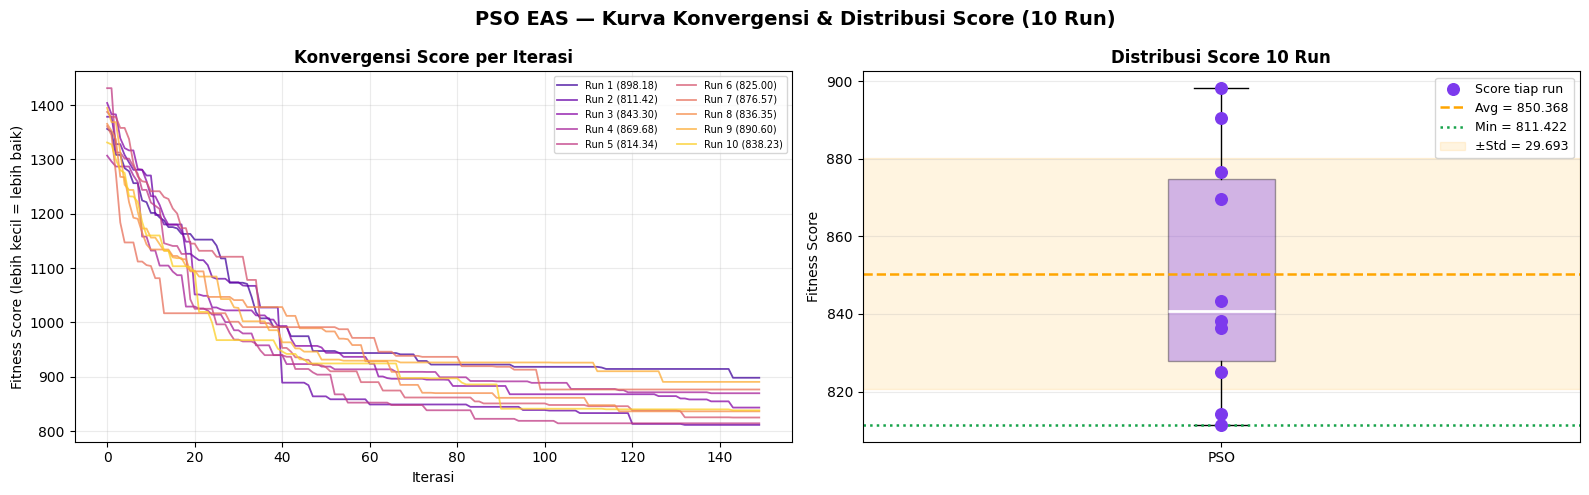

✅ Plot konvergensi tersimpan: hasil_optimasi_eas/pso_konvergensi_10run.png


In [10]:
# ==========================================
# 9) PLOT KONVERGENSI & DISTRIBUSI (10 RUN)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("PSO EAS — Kurva Konvergensi & Distribusi Score (10 Run)",
             fontsize=14, fontweight="bold")

# Panel Kiri: Kurva Konvergensi tiap Run
ax1 = axes[0]
palette = plt.cm.plasma(np.linspace(0.1, 0.9, 10))
for idx, res in enumerate(pso_all_results):
    ax1.plot(res["ScoreHistory"], color=palette[idx], alpha=0.75, linewidth=1.3,
             label=f"Run {res['Run']} ({res['Score']:.2f})")
ax1.set_title("Konvergensi Score per Iterasi", fontweight="bold")
ax1.set_xlabel("Iterasi")
ax1.set_ylabel("Fitness Score (lebih kecil = lebih baik)")
ax1.legend(fontsize=7, ncol=2, loc="upper right")
ax1.grid(True, alpha=0.25)

# Panel Kanan: Boxplot + strip per Run
ax2 = axes[1]
score_vals = [r["Score"] for r in pso_all_results]
run_labels = [f"R{r['Run']}" for r in pso_all_results]

ax2.boxplot(score_vals, patch_artist=True,
            boxprops=dict(facecolor="#7c3aed", alpha=0.35),
            medianprops=dict(color="white", linewidth=2),
            flierprops=dict(marker="x", color="gray"))
ax2.scatter([1] * len(score_vals), score_vals, color="#7c3aed", zorder=5, s=70,
            label="Score tiap run")
ax2.axhline(avg_score, color="orange", linestyle="--", linewidth=1.8,
            label=f"Avg = {avg_score:.3f}")
ax2.axhline(min_score, color="#16a34a", linestyle=":",  linewidth=1.8,
            label=f"Min = {min_score:.3f}")
ax2.fill_between([0.5, 1.5], avg_score - std_score, avg_score + std_score,
                 color="orange", alpha=0.12, label=f"±Std = {std_score:.3f}")
ax2.set_title("Distribusi Score 10 Run", fontweight="bold")
ax2.set_ylabel("Fitness Score")
ax2.set_xticks([1]); ax2.set_xticklabels(["PSO"])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plot1_path = os.path.join(OUT_DIR, "pso_konvergensi_10run.png")
plt.savefig(plot1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Plot konvergensi tersimpan: {plot1_path}")

In [ ]:
# ==========================================
# 10) BAR CHART STATISTIK (Avg / Std / Min / Avg Time)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("PSO EAS — Ringkasan Statistik 10 Run", fontsize=13, fontweight="bold")

runs_x  = [r["Run"]   for r in pso_all_results]
score_y = [r["Score"] for r in pso_all_results]
time_y  = [r["Time_s"] for r in pso_all_results]

# Panel Kiri: Score per Run
ax = axes[0]
bar_colors = ["#16a34a" if s == min_score else "#4f46e5" for s in score_y]
bars = ax.bar(runs_x, score_y, color=bar_colors, edgecolor="white", linewidth=0.8)
ax.axhline(avg_score, color="orange", linestyle="--", linewidth=1.8,
           label=f"Avg = {avg_score:.3f}")
ax.axhline(min_score, color="#16a34a", linestyle=":", linewidth=1.8,
           label=f"Min = {min_score:.3f}")
ax.fill_between([0.4, 10.6], avg_score - std_score, avg_score + std_score,
                color="orange", alpha=0.12, label=f"±Std = {std_score:.3f}")
for bar, s in zip(bars, score_y):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(score_y) * 0.003,
            f"{s:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_title("Fitness Score per Run", fontweight="bold")
ax.set_xlabel("Run ke-"); ax.set_ylabel("Fitness Score")
ax.set_xticks(runs_x); ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis="y")

# Panel Kanan: Running Time per Run
ax2 = axes[1]
bars2 = ax2.bar(runs_x, time_y, color="#0ea5e9", edgecolor="white", linewidth=0.8)
ax2.axhline(avg_time, color="red", linestyle="--", linewidth=1.8,
            label=f"Avg Time = {avg_time:.3f}s")
for bar, t in zip(bars2, time_y):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(time_y) * 0.01,
             f"{t:.2f}s", ha="center", va="bottom", fontsize=8)
ax2.set_title("Running Time per Run", fontweight="bold")
ax2.set_xlabel("Run ke-"); ax2.set_ylabel("Waktu (detik)")
ax2.set_xticks(runs_x); ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
stat_path = os.path.join(OUT_DIR, "pso_statistik_ringkasan.png")
plt.savefig(stat_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Bar chart statistik tersimpan: {stat_path}")

In [ ]:
# ==========================================
# 11) VISUALISASI RUTE TERBAIK PSO
#     (Peta + Profil Elevasi + Fatigue)
# ==========================================
best_route = pso_best_overall_route
_, best_dist, best_fat, best_viol, fat_hist = get_metrics(best_route)

cluster_color_map = {0: "#ef4444", 1: "#3b82f6", 2: "#22c55e"}

fig = plt.figure(figsize=(18, 10))
fig.suptitle(f"PSO EAS — Rute Terbaik  |  Score={pso_s:.3f}  Dist={pso_d:.2f}km"
             f"  Fatigue={pso_f:.2f}  Viol={pso_v}",
             fontsize=13, fontweight="bold")

gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
ax_map  = fig.add_subplot(gs[:, 0])
ax_elev = fig.add_subplot(gs[0, 1])
ax_fat  = fig.add_subplot(gs[1, 1])

# ── Peta Rute ────────────────────────────────────────────────
for c_id, c_col in cluster_color_map.items():
    idx_list = [i for i, cl in enumerate(cluster_labels) if cl == c_id]
    lats_c   = [coords_values[i][0] for i in idx_list]
    lons_c   = [coords_values[i][1] for i in idx_list]
    ax_map.scatter(lons_c, lats_c, s=70, color=c_col, zorder=3,
                   label=f"Kluster {c_id}")

route_lats = [coords_values[i][0] for i in best_route]
route_lons = [coords_values[i][1] for i in best_route]
ax_map.plot(route_lons, route_lats, "k--", linewidth=1.1, alpha=0.45, zorder=2)

depot_lat, depot_lon = coords_values[start_location_idx]
ax_map.scatter([depot_lon], [depot_lat], s=250, color="gold",
               edgecolors="black", linewidths=1.8, zorder=6, label="Depot")

for order, idx in enumerate(best_route):
    lat, lon = coords_values[idx]
    ax_map.annotate(str(order), (lon, lat), fontsize=6,
                    ha="center", va="center", color="white",
                    bbox=dict(boxstyle="circle,pad=0.18", fc="navy", ec="none", alpha=0.65))

ax_map.set_title("Peta Rute (warna = kluster)", fontweight="bold")
ax_map.set_xlabel("Longitude"); ax_map.set_ylabel("Latitude")
ax_map.legend(fontsize=8, loc="lower right")
ax_map.grid(True, alpha=0.2)

# ── Profil Elevasi ────────────────────────────────────────────
elev_seq = [elevations_list[i] for i in best_route]
x_seq    = list(range(len(best_route)))
ax_elev.fill_between(x_seq, elev_seq, alpha=0.25, color="#a78bfa")
ax_elev.plot(x_seq, elev_seq, color="#7c3aed", linewidth=2)
ax_elev.axhline(np.mean(elev_seq), color="orange", linestyle="--", linewidth=1.2,
                label=f"Rata-rata {np.mean(elev_seq):.1f} m")
ax_elev.set_title("Profil Elevasi", fontweight="bold")
ax_elev.set_xlabel("Urutan Kunjungan"); ax_elev.set_ylabel("Elevasi (m dpl)")
ax_elev.legend(fontsize=8); ax_elev.grid(True, alpha=0.25)

# ── Profil Fatigue ────────────────────────────────────────────
ax_fat.fill_between(range(len(fat_hist)), fat_hist, alpha=0.25, color="#f97316")
ax_fat.plot(fat_hist, color="#ea580c", linewidth=2)
ax_fat.axhline(EXTREME_EFFORT_M, color="red", linestyle=":", linewidth=1.2,
               label=f"Threshold = {EXTREME_EFFORT_M} m")
ax_fat.set_title("Akumulasi Fatigue Sepanjang Rute", fontweight="bold")
ax_fat.set_xlabel("Urutan Kunjungan"); ax_fat.set_ylabel("Fatigue Index")
ax_fat.legend(fontsize=8); ax_fat.grid(True, alpha=0.25)

plt.savefig(os.path.join(OUT_DIR, "pso_rute_terbaik.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisasi rute terbaik tersimpan.")

In [ ]:
# ==========================================
# 12) PETA INTERAKTIF FOLIUM — RUTE TERBAIK PSO
# ==========================================
center_lat = np.mean([c[0] for c in coords_values])
center_lon = np.mean([c[1] for c in coords_values])

m = folium.Map(location=[center_lat, center_lon], zoom_start=14, control_scale=True)

# Warna marker per kluster
folium_colors = {0: "red", 1: "blue", 2: "green"}

# Marker setiap destinasi
for idx, name in enumerate(names):
    lat, lon = coords_values[idx]
    c_id     = int(cluster_labels[idx])
    is_depot = (idx == start_location_idx)
    color    = "orange" if is_depot else folium_colors[c_id]
    icon     = "home"   if is_depot else "info-sign"
    popup_txt = (f"<b>{name}</b><br>"
                 f"Elevasi: {elevations_list[idx]} mdpl<br>"
                 f"Kluster: {c_id}<br>"
                 f"Road Score (dari depot): {road_matrix[start_location_idx][idx]:.1f}")
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_txt, max_width=260),
        tooltip=name,
        icon=folium.Icon(color=color, icon=icon)
    ).add_to(m)

# Garis rute PSO terbaik
route_coords = [(coords_values[i][0], coords_values[i][1]) for i in best_route]
folium.PolyLine(route_coords, color="#7c3aed", weight=3.5, opacity=0.8,
                tooltip=f"Rute PSO Terbaik | Score={pso_s:.2f}").add_to(m)

# Nomor urutan kunjungan (DivIcon)
for order, idx in enumerate(best_route[:-1]):
    lat, lon = coords_values[idx]
    folium.Marker(
        location=[lat, lon],
        icon=folium.DivIcon(
            html=(f'<div style="font-size:9px;font-weight:bold;'
                  f'background:#1e1b4b;color:white;border-radius:50%;'
                  f'width:19px;height:19px;display:flex;align-items:center;'
                  f'justify-content:center;">{order}</div>'),
            icon_size=(19, 19), icon_anchor=(9, 9),
        )
    ).add_to(m)

map_path = os.path.join(OUT_DIR, "pso_peta_interaktif.html")
m.save(map_path)
print(f"✅ Peta interaktif tersimpan: {map_path}")
m

In [ ]:
# ==========================================
# 13) KESIMPULAN AKHIR PSO EAS
# ==========================================
print("\n" + "=" * 75)
print("🏆  KESIMPULAN AKHIR — PSO EAS")
print("=" * 75)

print("\n📌 Hyperparameter Terpilih (Optuna, 30 trials):")
print(f"   num_particles = {best_pso_params['num_particles']}")
print(f"   w  (inersia)  = {best_pso_params['w']:.6f}")
print(f"   c1 (kognitif) = {best_pso_params['c1']:.6f}")
print(f"   c2 (sosial)   = {best_pso_params['c2']:.6f}")

print("\n📊 Statistik 10 Independent Run:")
print(f"   Avg Score        : {avg_score:.4f}")
print(f"   Std Dev Score    : {std_score:.4f}"
      + ("  (stabil ✔)" if std_score < avg_score * 0.05 else "  (bervariasi)"))
print(f"   Min Score (Best) : {min_score:.4f}")
print(f"   Avg Running Time : {avg_time:.3f} s")

print("\n🎯 Rute Terbaik:")
print(f"   Fitness Score  : {pso_s:.4f}")
print(f"   Total Jarak    : {pso_d:.4f} km")
print(f"   Max Fatigue    : {pso_f:.4f}")
print(f"   Violations     : {pso_v}")
route_named = [names[i] for i in pso_best_overall_route]
print(f"   Urutan ({len(pso_best_overall_route)} langkah):")
for step, nm in enumerate(route_named):
    print(f"     {step:>2}. {nm}")

print("\n🔧 Constraint yang Diterapkan:")
print(f"   ✔ [ETS] Fatigue penalty         λ={LAMBDA_FATIGUE}, R={RECOVERY_FACTOR}")
print(f"   ✔ [ETS] Elevation violation      threshold={EXTREME_EFFORT_M}m, μ={MU_VIOLATIONS}")
print(f"   ✔ [EAS] Road condition matrix    intra=1.5, cross=4.0, w={W_ROAD}")
print(f"   ✔ [EAS] Cluster guidance penalty w={W_CLUSTER_PEN}")
print(f"   ✔ [EAS] Soft daily dist penalty  max={MAX_KM_PER_DAY}km, w={W_DAY_DIST_PEN}")

print("\n📂 File Output (folder: hasil_optimasi_eas/):")
for fname in ["pso_eas_10run_results.csv",
              "pso_konvergensi_10run.png",
              "pso_statistik_ringkasan.png",
              "pso_rute_terbaik.png",
              "pso_peta_interaktif.html",
              "distance_matrix_km.npy"]:
    print(f"   📄 {fname}")
print("=" * 75)